<a href="https://colab.research.google.com/github/aditya0589/notebooks/blob/main/AI%20Engineering/Langchain/LC05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LC05 Langchain Expression Language**

## **Chains**

When we create applications using Large Language models, we find that the application usually is made of multiple small parts. Even a simple application of taking a user input and returning a LLM response has multiple steps involved in it.

 step 1: Take the user prompt

 step2: pass the prompt to the LLM and get the output.

 step3: process the output and present it to the user.

 Designing and executing these various steps individually is a gruelling and time consuming task.

 Langchain **Chains** allows you to streamline this process by developing a pipeline which consists of these various components. This prevents the user from manually defining each component and makes the code more easy and clean.

 Chains allow you to build highly complex LLM applications in a very simple manner

In [1]:
import os
from google.colab import userdata

# Load keys from Colab Secrets
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
os.environ['HUGGINGFACEHUB_API_TOKEN'] = userdata.get('HUGGINGFACEHUB_API_TOKEN')

# Sanity check (safe partial print)
print("Groq:", os.environ["GROQ_API_KEY"][:8])
print("Google:", os.environ["GOOGLE_API_KEY"][:8])
print('HF_TOKEN', os.environ['HF_TOKEN'][:8])
print('huggingface api token', os.environ['HUGGINGFACEHUB_API_TOKEN'][:8])

Groq: gsk_L243
Google: AIzaSyCX
HF_TOKEN AIzaSyBE
huggingface api token hf_SMPRD


In [2]:
!pip install langchain langchain_core langchain_community langchain_groq

In [3]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [4]:
prompt  = PromptTemplate(
    template = "generate 5 interesting facts about {topic}",
    input_variables = ["topic"]
)


In [5]:
model = ChatGroq(
    model_name = "llama-3.1-8b-instant"
)

parser = StrOutputParser()
chain = prompt | model | parser

print(chain.invoke({"topic": "lannisters"}))

Here are 5 interesting facts about the Lannisters from the Game of Thrones series:

1. **The Lannister Motto is a Reference to their Alleged Origins**: The Lannister family motto is "Hear Me Roar!" which is a reference to their supposed origins from the mythical Golden Lion of Casterly Rock. According to legend, the Golden Lion was said to have roared so loudly that its sound could be heard across the Seven Kingdoms.

2. **The Lannisters are Originally from a Region Called the Rock**: In the Game of Thrones series, the Lannisters are from a region called the Rock, which is located in the Westerlands. The Rock is said to be a rocky and barren region, which is fitting given the Lannisters' reputation as a proud and unyielding family.

3. **The Lannisters are Known for their Gold and Wealth**: The Lannisters are one of the wealthiest and most powerful families in the Seven Kingdoms, thanks to their control of the iron mines of the Crag, the gold mines of Casterly Rock, and their extensive

From the above example, we find that we can easily integrate complex components using chains

## **Sequential Chains**

We will be building the following scenario:

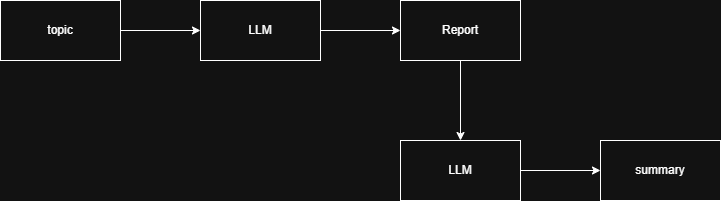

In [6]:
prompt1 = PromptTemplate(
    template= "Generate a detailed report on the topic {topic}",
    input_variables= ["topic"]
)

prompt2 = PromptTemplate(
    template="Write a 5 point summary of the following report: {report}",
    input_variables= ["report"]
)

In [7]:
model = ChatGroq(
    model_name = "llama-3.1-8b-instant"
)

parser = StrOutputParser()

In [8]:
chain = prompt1 | model | parser | prompt2 | model | parser

result = chain.invoke({"topic": "Lewis Hamilton"})

print(result)

Here's a 5-point summary of the report on Lewis Hamilton:

1. **Early Life and Career**: Lewis Hamilton was born on January 7, 1985, in Stevenage, England, and began his karting career at the age of eight. He showed a natural talent for the sport and won several championships, including the Cadet Karting World Championship in 1996 and the Junior Karting World Championship in 2000.

2. **Formula One Career**: Hamilton made his Formula One debut with McLaren in 2007 and won his first World Championship in 2008. He then joined Mercedes-AMG Petronas F1 Team in 2013 and has since won seven Formula One World Championships (2014, 2015, 2017, 2018, 2019, 2020, and 2021) and 103 Grands Prix.

3. **Achievements**: Hamilton's achievements extend beyond Formula One, with two Olympic medals (Gold and Silver) in the 2008 Beijing Olympics, an IAAF Diamond League championship in the 100m sprint in 2012, and FIA Formula One Team Champion awards (2014, 2017, 2018, and 2019).

4. **Personal Life**: Hamil

## **Parallel Chain**

We want to create an application that takes a user document (on any subject) and then generates a detailed notes on it as well as a quiz and display it to the user at once.

This can be done in the following way:

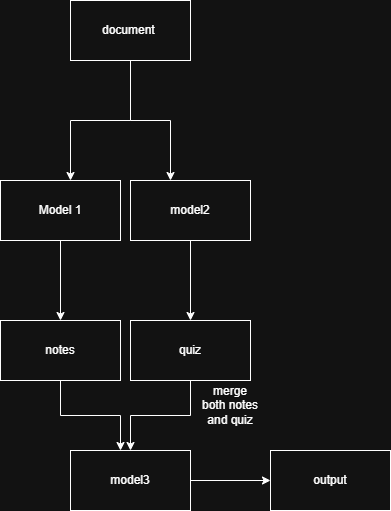

In [9]:
model1 = ChatGroq(
    model_name = "llama-3.1-8b-instant"
)

model2 = ChatGroq(
    model_name = "llama-3.1-8b-instant"
)

model3 = ChatGroq(
    model_name = "llama-3.1-8b-instant"
)

In [10]:
prompt1 = PromptTemplate(
    template = "Take the document {text} and generate detailed notes for it",
    input_variables = ["text"]
)

prompt2 = PromptTemplate(
    template = "Take the document {text} and generate a quiz for it",
    input_variables = ["text"]
)

prompt3 = PromptTemplate(
    template = "Take both the quiz and the notes and merge them into a single document notes: {notes}, quiz: {quiz}",
    input_variables = ["notes", "quiz"]
)

In [11]:
from langchain_core.runnables import RunnableParallel

parser = StrOutputParser()

In [12]:
parallel_chain = RunnableParallel(
    notes = prompt1 | model1 | parser,
    quiz = prompt2 | model2 | parser
)

In [13]:
merge_chain = prompt3 | model2 | parser

chain = parallel_chain | merge_chain

In [14]:
text = """
The American War of Independence, also known as the American Revolutionary War, was a major conflict fought between Great Britain and thirteen of its North American colonies. The war lasted from 1775 to 1783 and resulted in the colonies gaining independence and forming the United States of America. It was one of the most important political revolutions in world history, establishing the idea that colonies could challenge imperial rule and form their own nation based on democratic principles.

Background and Causes

During the 18th century, the thirteen British colonies in North America had developed economically and socially but remained under British control. After the costly Seven Years’ War (1756–1763), Britain faced heavy debts and decided to increase taxes in its colonies to raise revenue. Several laws were introduced, including the Stamp Act (1765), the Townshend Acts (1767), and the Tea Act (1773). These taxes were imposed without giving the colonists representation in the British Parliament.

The colonists strongly opposed these measures, arguing that taxation without representation was unjust. Protests, boycotts, and political resistance spread across the colonies. One of the most famous protests was the Boston Tea Party in 1773, where American colonists threw British tea into Boston Harbor as a sign of resistance against the Tea Act.

In response, the British government imposed strict laws known as the Intolerable Acts to punish the colony of Massachusetts. Instead of suppressing resistance, these measures united the colonies further. In 1774, representatives from the colonies met at the First Continental Congress to coordinate their response to British policies.

Beginning of the War

The conflict began in April 1775 with the Battles of Lexington and Concord in Massachusetts. British troops were sent to seize colonial weapons stored by local militias, but the colonists resisted. These battles marked the start of open armed conflict between the British army and colonial forces.

Soon after, the Second Continental Congress was formed, and it organized a continental army to fight the British. George Washington was appointed as the commander-in-chief of the army. Washington played a crucial role in organizing and leading the colonial forces throughout the war.

Declaration of Independence

As tensions grew, many colonists began to support the idea of complete independence from Britain. On July 4, 1776, the Continental Congress adopted the Declaration of Independence. The document, largely written by Thomas Jefferson, declared that the thirteen colonies were free and independent states. It also emphasized the principles of liberty, equality, and the rights of individuals.

The Declaration of Independence became a powerful symbol of the American struggle for freedom and inspired other revolutionary movements around the world.
"""

In [15]:
result = chain.invoke({'text': text})

In [16]:
print(result)

**The American War of Independence**

**I. Overview**

- The American War of Independence, also known as the American Revolutionary War, was a major conflict between Great Britain and its thirteen North American colonies.
- The war lasted from 1775 to 1783 and resulted in the colonies gaining independence and forming the United States of America.
- It was one of the most important political revolutions in world history, establishing the idea that colonies could challenge imperial rule and form their own nation based on democratic principles.

**II. Background and Causes**

- The thirteen British colonies in North America had developed economically and socially but remained under British control during the 18th century.
- After the costly Seven Years’ War (1756–1763), Britain faced heavy debts and decided to increase taxes in its colonies to raise revenue.
- Several laws were introduced, including:
  - The Stamp Act (1765): imposed a tax on printed materials.
  - The Townshend Acts (176

## **Conditional Chains**

We want to build the following conditional system

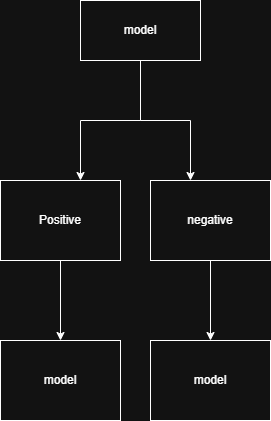

In [17]:
from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableLambda
from langchain_core.prompts import ChatPromptTemplate

# LLM
llm = ChatGroq(model_name="llama-3.1-8b-instant")

# Prompt for coding questions
coding_prompt = ChatPromptTemplate.from_template(
    "You are a Python expert. Answer the following coding question:\n{question}"
)

coding_chain = coding_prompt | llm

# Prompt for general questions
general_prompt = ChatPromptTemplate.from_template(
    "Answer the following general question:\n{question}"
)

general_chain = general_prompt | llm


# Conditional router
def route(info):
    question = info["question"].lower()

    if "python" in question:
        return coding_chain
    else:
        return general_chain


# Create conditional chain
router = RunnableLambda(route)

chain = router | (lambda x: x)


# Run chain
response = chain.invoke({"question": "How to create a list in python?"})

print(response.content)

**Creating a List in Python**

In Python, you can create a list using square brackets `[]` and separating elements with commas. Here are a few ways to create a list:

### Method 1: Initializing a List with Elements

```python
# Create a list with multiple elements
fruits = ["apple", "banana", "cherry"]
print(fruits)  # Output: ['apple', 'banana', 'cherry']

# Create an empty list
empty_list = []
print(empty_list)  # Output: []
```

### Method 2: Using the `list()` Function

```python
# Create a list from a string
string = "hello world"
list_from_string = list(string)
print(list_from_string)  # Output: ['h', 'e', 'l', 'l', 'o', ' ', 'w', 'o', 'r', 'l', 'd']

# Create a list from a tuple
tuple = (1, 2, 3, 4, 5)
list_from_tuple = list(tuple)
print(list_from_tuple)  # Output: [1, 2, 3, 4, 5]
```

### Method 3: Using List Comprehension

```python
# Create a list of squares from 1 to 5
squares = [x**2 for x in range(1, 6)]
print(squares)  # Output: [1, 4, 9, 16, 25]
```

### Method 4: Using 

# **Runnables**
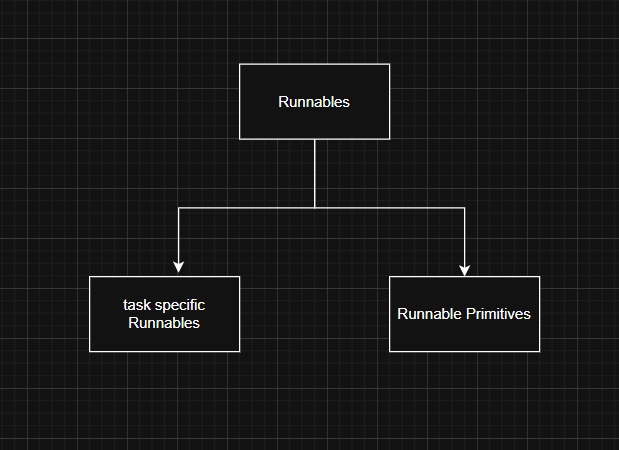




## **Task specific Runnables**

These are core langchain components that have been converted into runnables so that they can be used in pipelines.

They perform task specific operations like LLM calling, prompting, retrieval etc.

examples:

``ChatGroq`` - calls the Groq LLM API

``PromptTemplate`` - formats prompts dynamically

``Retriever`` - retireves relavent documents

---------------------------------------------------------------------------

## **Runnable Primitives**
These are fundamental building blocks for structuring execution logic in AI workflows

They help orchestrate execution by defining how different runnables interact (Sequentially, parallel, conditional etc)

Examples:

``RunnableSequence`` - runs steps in order

``RunnablePrallel`` - runs multiple steps simultaneously

``RunnableMap`` - maps the same input across multiple functions

``RunnableBranch`` - implements conditional execution (if-else statements)

``RunnableLambda`` - wraps custom python function into runnables

``RunnablePassthrough`` - just forwards input as output (acts as placeholder)


## **RunnableSequence**
RunnableSequence is a sequential chain of runnables in Langchain thay executes each step one after the other, passing the output of one step as input to the next step.

It is useful when you need to compose multiple runnables together in a structured workflow.


In [18]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableSequence

In [19]:
prompt  = PromptTemplate(
    template = "Write a joke about the following topic {topic}",
    input_variables = ["topic"]
)

model = ChatGroq(
    model_name = "llama-3.1-8b-instant"
)

parser = StrOutputParser()

runnable = RunnableSequence(prompt, model, parser)

result = runnable.invoke({"topic": "Artificial Intelligence"})

print(result)

Why did the AI program go to therapy?

Because it was struggling to process its emotions.


## **RunnableParallel**

Runnableparallel is a runnable primitive that allows multiple runnables to execute in parallel.

Each runnable recieves the same input and processes it independently, producing a dictionary of outputs.

In [20]:
from langchain_core.runnables import RunnableParallel

In [21]:
prompt1 = PromptTemplate(
    template = "Generate a tweet about the topic {topic}",
    input_variables = ["topic"]
)

prompt2 = PromptTemplate(
    template = "Generate a linkedin post about the topic {topic}",
    input_variables = ["topic"]
)

model = ChatGroq(
     model_name = "llama-3.1-8b-instant"
)

parser = StrOutputParser()

chain = RunnableParallel(
    tweet = RunnableSequence(prompt1, model, parser),
    linkedin = RunnableSequence(prompt2, model, parser)
)

result = chain.invoke({"topic": "AI"})

print(result)

{'tweet': '"The future is here! Artificial Intelligence is revolutionizing the way we live and work, from smart homes to intelligent assistants. What are the possibilities and challenges of a world where AI is increasingly integrated into our daily lives? #AI #FutureTech"', 'linkedin': "Here's a potential LinkedIn post about AI:\n\n**The Future of Work is Here: How AI is Revolutionizing Industries**\n\nAs we continue to navigate the ever-changing landscape of the modern workplace, one thing is clear: Artificial Intelligence (AI) is no longer just a buzzword - it's a reality that's transforming industries and revolutionizing the way we work.\n\nFrom predictive analytics to natural language processing, AI is enabling businesses to automate tasks, enhance customer experiences, and make data-driven decisions with unprecedented speed and accuracy. But what does this mean for you?\n\nWhether you're a seasoned leader or a rising star, AI is an opportunity to upskill, reskill, and take your ca

In [22]:
print(result['tweet'])

"The future is here! Artificial Intelligence is revolutionizing the way we live and work, from smart homes to intelligent assistants. What are the possibilities and challenges of a world where AI is increasingly integrated into our daily lives? #AI #FutureTech"


In [23]:
print(result['linkedin'])

Here's a potential LinkedIn post about AI:

**The Future of Work is Here: How AI is Revolutionizing Industries**

As we continue to navigate the ever-changing landscape of the modern workplace, one thing is clear: Artificial Intelligence (AI) is no longer just a buzzword - it's a reality that's transforming industries and revolutionizing the way we work.

From predictive analytics to natural language processing, AI is enabling businesses to automate tasks, enhance customer experiences, and make data-driven decisions with unprecedented speed and accuracy. But what does this mean for you?

Whether you're a seasoned leader or a rising star, AI is an opportunity to upskill, reskill, and take your career to the next level. By embracing AI, you'll be able to:

 * Enhance your productivity and efficiency
 * Improve your decision-making and problem-solving skills
 * Stay ahead of the curve in a rapidly evolving job market

At [Your Company/Industry], we're committed to harnessing the power of 

## **RunnablePassthrough**

It is a simple runnable primitive which returns the input as output without modifying it.



In [24]:
from langchain_core.runnables import RunnablePassthrough


In [25]:
passthrough = RunnablePassthrough()

result = passthrough.invoke(2)

print(result)

2


In [26]:
result2 = passthrough.invoke({'name': 'Donald Trump'})

print(result2)

{'name': 'Donald Trump'}


In [27]:
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

prompt = PromptTemplate(
    template="Write a joke about the following topic {topic}",
    input_variables=["topic"]
)

prompt2 = PromptTemplate(
    template="Explain the following joke: {joke}",
    input_variables=["joke"]
)

model = ChatGroq(
    model_name="llama-3.1-8b-instant"
)

parser = StrOutputParser()

# Chain to generate joke
joke_chain = prompt | model | parser

# Runnable with passthrough
runnable = RunnableParallel(
    joke=joke_chain,
    explanation=RunnablePassthrough()
        | joke_chain
        | (lambda joke: {"joke": joke})
        | prompt2
        | model
        | parser
)

result = runnable.invoke({"topic": "Artificial Intelligence"})

print(result)

{'joke': 'Why did the AI program go to therapy?\n\nBecause it was struggling to process its emotions, but it was always able to reboot and start again.', 'explanation': 'This joke relies on a play on words and a mix of technological and psychological references. \n\nIn computer science, a \'bug\' is often used to refer to a software error or a problem that causes an application to malfunction. \n\nIn therapy, a \'bug\' would typically refer to a flaw or an imperfection in someone\'s behavior or personality that they are trying to overcome or work through.\n\nThe joke combines these two meanings by saying the AI program is "struggling with a little \'bug\' in its personality." This is humorous because it takes the common tech term ("bug") and applies it to a psychological context ("personality bug"), implying that the AI is experiencing some kind of glitch that needs to be fixed, much like a software bug. \n\nThe punchline is funny because it takes a common tech problem (a software bug)

## **RunnableLambda**

RunnableLambda is a runnable primitive that allows you to apply custom python functions within the AI pipeline.

It acts as a middleware between different AI components, enabling preprocessing, transformation, API calls, filtering, and post-processing in langchain workflow.

In [29]:
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

# Prompt
prompt = PromptTemplate(
    template="Write a short joke about {topic}",
    input_variables=["topic"]
)

# Model
model = ChatGroq(
    model_name="llama-3.1-8b-instant"
)

# Parser
parser = StrOutputParser()

# Function to count words
def count_words(joke):
    word_count = len(joke.split())
    return {
        "joke": joke,
        "word_count": word_count
    }

# Convert function into runnable
word_counter = RunnableLambda(count_words)

# Chain
chain = prompt | model | parser | word_counter

# Run
result = chain.invoke({"topic": "Artificial Intelligence"})

print("Joke:", result["joke"])
print("Word Count:", result["word_count"])

Joke: Why did the AI program go to therapy?

Because it had a lot of 'bugged' relationships and was struggling to 'process' its emotions.
Word Count: 23


## **RunnableBranch**
RunnableBranch is a control flow component in langchain that allows you to conditionally route input data to different chains or runnables based on custom logic.

if functions like an if/else block for chains - where you define a set of condition functions, each associated with a runnable. the first matching condition is executed. if no condition matches, a default condition can be provided.


In [32]:
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableBranch

# Model
model = ChatGroq(model_name="llama-3.1-8b-instant")

parser = StrOutputParser()

# Prompt for joke
joke_prompt = PromptTemplate(
    template="Write a funny joke about {topic}",
    input_variables=["topic"]
)

# Prompt for explanation
explain_prompt = PromptTemplate(
    template="Explain the concept of {topic} in simple terms",
    input_variables=["topic"]
)

# Chains
joke_chain = joke_prompt | model | parser
explain_chain = explain_prompt | model | parser

# Branch logic
branch = RunnableBranch(
    (lambda x: x["mode"] == "joke", joke_chain),
    explain_chain  # default branch
)

# Run
result = branch.invoke({
    "topic": "Artificial Intelligence",
    "mode": "story"
})

print(result)

**What is Artificial Intelligence (AI)?**

Artificial Intelligence (AI) is a way to create machines or computers that can think, learn, and act like humans. It's like teaching a robot or a computer system to make decisions, solve problems, and perform tasks on its own.

**How does AI work?**

Imagine you have a friend who is really good at recognizing pictures of dogs and cats. You could teach this friend to recognize more pictures of animals, and eventually, they could identify almost any animal. AI works in a similar way. It uses algorithms (step-by-step instructions) and data to learn and improve over time.

**Types of AI:**

There are three main types of AI:

1. **Narrow or Weak AI**: This type of AI is designed to perform a specific task, like facial recognition, language translation, or playing chess. It's like a robot that can only do one thing.
2. **General or Strong AI**: This type of AI is designed to perform any intellectual task that a human can. It's like a super-intellige